In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

results = pd.read_csv("results/results.csv")
curves = pd.read_csv("results/learning_curves.csv")

print(results.shape)
results.head()

(30, 15)


,experiment_id,method,seed,batch_size,epochs,rank,best_epoch,best_val_loss,final_train_loss,final_val_loss,train_acc,val_acc,train_f1,val_f1,training_time_seconds
0,1,full,42,64,30,NaN,28,0.366235,0.342428,0.487957,0.83632,0.8298,0.827711,0.818929,236.677675
1,2,lora,42,64,30,1.0,29,0.679353,0.685249,0.679353,0.75822,0.7561,0.752967,0.749721,86.132886
2,3,lora,42,64,30,2.0,28,0.577991,0.579311,0.596275,0.78980,0.7913,0.785424,0.786096,74.413542
3,4,lora,42,64,30,4.0,28,0.507865,0.507028,0.520163,0.81886,0.8143,0.811350,0.806067,72.804538
4,5,lora,42,64,30,8.0,28,0.480719,0.478883,0.482401,0.83458,0.8295,0.831788,0.826139,73.823306


In [26]:
summary = (
    results
    .groupby(["method", "rank"])
    .agg(
        val_acc_mean=("val_acc", "mean"),
        val_acc_std=("val_acc", "std"),
        val_f1_mean=("val_f1", "mean"),
        val_f1_std=("val_f1", "std"),
        best_val_loss_mean=("best_val_loss", "mean"),
        training_time_mean=("training_time_seconds", "mean"),
    )
    .reset_index()
)

summary.sort_values(["method", "rank"])

results.sort_values(
    "val_f1",
    ascending=False
).head(10)

,experiment_id,method,seed,batch_size,epochs,rank,best_epoch,best_val_loss,final_train_loss,final_val_loss,train_acc,val_acc,train_f1,val_f1,training_time_seconds
12,13,full,456,64,30,NaN,29,0.366008,0.351307,0.366008,0.88124,0.8689,0.879815,0.868024,253.556342
18,19,full,789,64,30,NaN,28,0.381772,0.345855,0.385062,0.87854,0.8654,0.878401,0.864480,288.177457
6,7,full,123,64,30,NaN,26,0.385884,0.342018,0.389686,0.88000,0.8602,0.879814,0.862017,220.646058
24,25,full,999,64,30,NaN,28,0.368749,0.346774,0.389635,0.87362,0.8628,0.873535,0.861533,267.823790
5,6,lora,42,64,30,16.0,29,0.457839,0.460981,0.457839,0.84258,0.8396,0.842009,0.838422,78.704756
28,29,lora,999,64,30,8.0,28,0.469888,0.472460,0.470124,0.83616,0.8374,0.834475,0.833595,66.810236
29,30,lora,999,64,30,16.0,27,0.468631,0.467551,0.469259,0.83386,0.8379,0.830276,0.831648,63.459972
16,17,lora,456,64,30,8.0,29,0.481926,0.481029,0.481926,0.82832,0.8315,0.826301,0.830408,93.085311
23,24,lora,789,64,30,16.0,28,0.473543,0.462315,0.482374,0.83762,0.8306,0.837149,0.829561,91.391802
15,16,lora,456,64,30,4.0,29,0.496510,0.502634,0.496510,0.82338,0.8273,0.824275,0.829077,92.633278


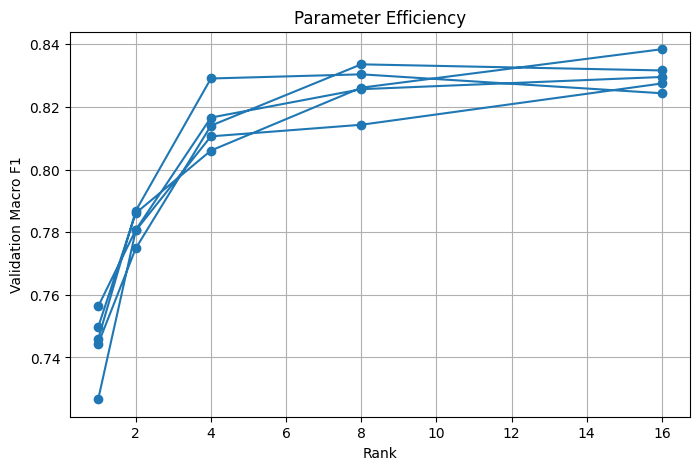

In [ ]:

plot_stats = results.copy()


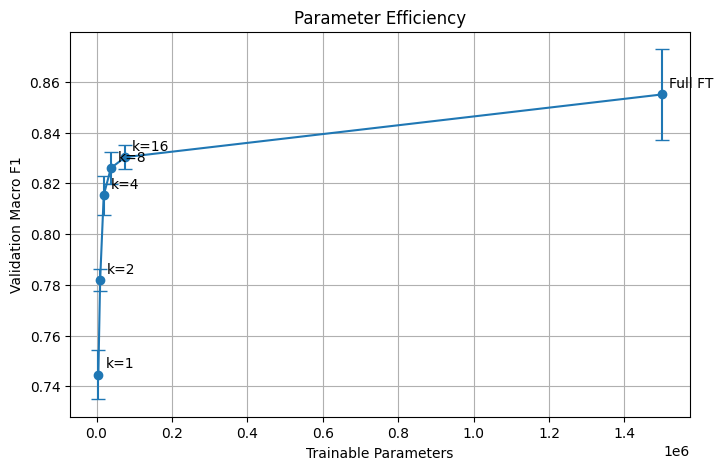

In [34]:
rank_to_params = {
    1: 4_762,
    2: 9_524,
    4: 19_048,
    8: 38_096,
    16: 76_192,
}

plot_stats["params"] = plot_stats["rank"].map(rank_to_params)


# Full FT parameter count
plot_stats.loc[
    plot_stats["method"] == "full",
    "params"
] = 1_499_776

plot_stats["model"] = plot_stats.apply(
    lambda row: (
        "Full FT"
        if row["method"] == "full"
        else f"k={int(row['rank'])}"
    ),
    axis=1
)

def ci95(x):
    return 1.96 * np.std(x, ddof=1) / np.sqrt(len(x))

summary = (
    plot_stats
    .groupby(["model", "params"])
    .agg(
        mean_f1=("val_f1", "mean"),
        ci=("val_f1", ci95)
    )
    .reset_index()
    .sort_values("params")
)

plt.figure(figsize=(8, 5))

plt.errorbar(
    summary["params"],
    summary["mean_f1"],
    yerr=summary["ci"],
    marker="o",
    capsize=5
)

for _, row in summary.iterrows():
    plt.annotate(
        row["model"],
        (row["params"], row["mean_f1"]),
        xytext=(5, 5),
        textcoords="offset points"
    )

# plt.xscale("log")  # highly recommended

plt.xlabel("Trainable Parameters")
plt.ylabel("Validation Macro F1")
plt.title("Parameter Efficiency")
plt.grid(True)

plt.show()

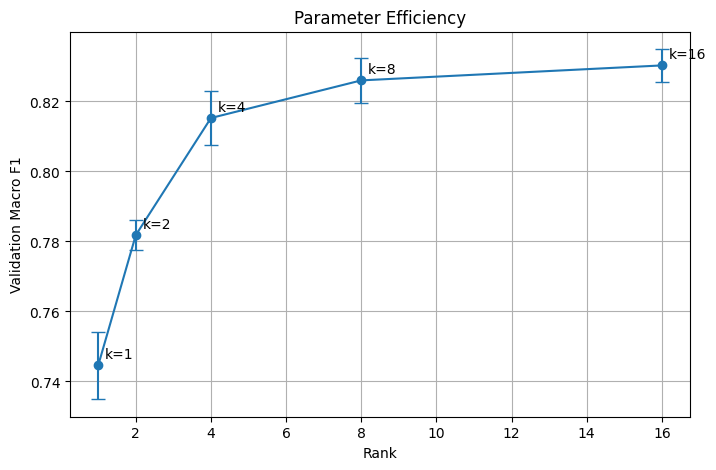

In [36]:
lora_summary = summary[summary["model"] != "Full FT"].copy()
lora_summary["rank"] = lora_summary["model"].apply(lambda x: int(x.split("=")[1]))

plt.figure(figsize=(8, 5))

plt.errorbar(
    lora_summary["rank"],
    lora_summary["mean_f1"],
    yerr=lora_summary["ci"],
    marker="o",
    capsize=5
)

for _, row in lora_summary.iterrows():
    plt.annotate(
        row["model"],
        (row["rank"], row["mean_f1"]),
        xytext=(5, 5),
        textcoords="offset points"
    )

# plt.xscale("log")  # highly recommended

plt.xlabel("Rank")
plt.ylabel("Validation Macro F1")
plt.title("Parameter Efficiency")
plt.grid(True)

plt.show()

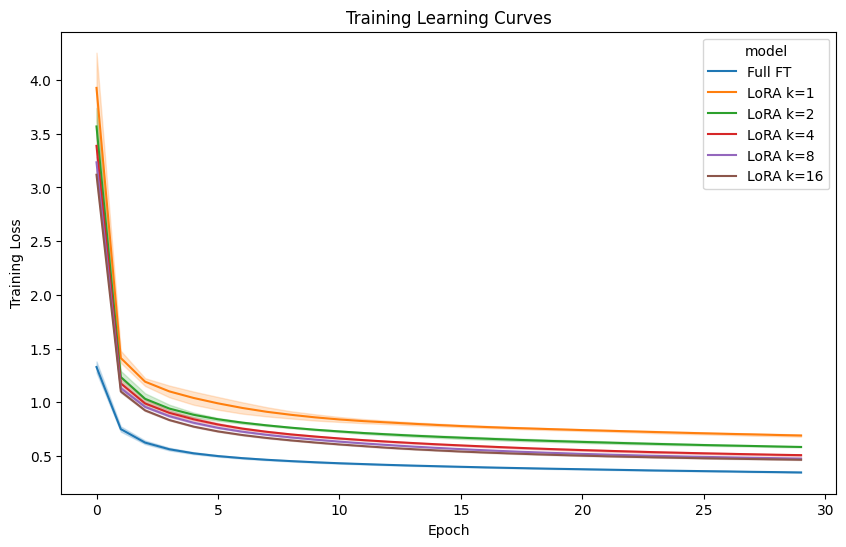

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

plot_df = curves.merge(
    results[["experiment_id", "method", "rank", "seed"]],
    on="experiment_id"
)
plot_df["model"] = plot_df.apply(
    lambda row: (
        "Full FT"
        if row["method"] == "full"
        else f"LoRA k={int(row['rank'])}"
    ),
    axis=1
)

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=plot_df,
    x="epoch",
    y="train_loss",
    hue="model",
    estimator="mean",
    errorbar=("ci", 95),
)

plt.title("Training Learning Curves")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")

plt.show()


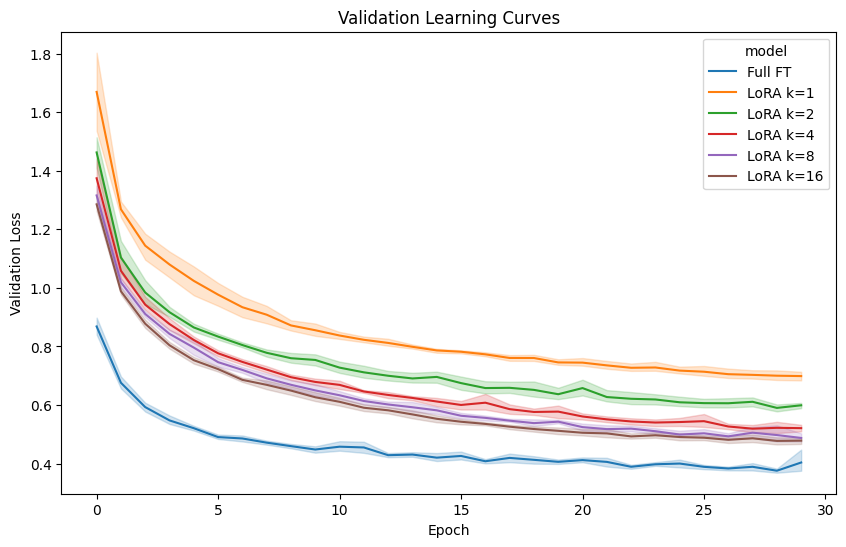

In [31]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=plot_df,
    x="epoch",
    y="val_loss",
    hue="model",
    estimator="mean",
    errorbar=("ci", 95),
)

plt.title("Validation Learning Curves")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")

plt.show()